
1. Question Statement

Given the following data, fit a quadratic polynomial regression model and obtain the regression equation.

X:
1
2
3
4

Y:  1 4 9 15

The quadratic regression model is:

$$ \boxed{y=a_0+a_1x+a_2x^2} $$

Find \(a0,a1,a2\) and hence obtain the quadratic regression equation.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


In [3]:
X = np.array([[1], [2], [3], [4]])
Y = np.array([1, 4, 9, 15])

In [4]:
# Convert X into polynomial features: 1, x, x^2
poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

print("Polynomial Features:")
print(X_poly)

Polynomial Features:
[[ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  3.  9.]
 [ 1.  4. 16.]]


In [5]:
# Create Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_poly, Y)

# Get coefficients
a0 = model.intercept_
a1 = model.coef_[1]
a2 = model.coef_[2]

print("\nCoefficients:")
print("a0 =", a0)
print("a1 =", a1)
print("a2 =", a2)

# Regression equation
print("\nQuadratic Regression Equation:")
print(f"y = {a0:.2f} + {a1:.2f}x + {a2:.2f}x^2")


Coefficients:
a0 = -0.7499999999999964
a1 = 0.9500000000000011
a2 = 0.7499999999999992

Quadratic Regression Equation:
y = -0.75 + 0.95x + 0.75x^2


In [6]:
# Predict existing values
Y_pred = model.predict(X_poly)

print("\nActual Y:")
print(Y)

print("\nPredicted Y:")
print(Y_pred)

# Predict for x = 5
new_X = np.array([[5]])
new_X_poly = poly.transform(new_X)

prediction = model.predict(new_X_poly)

print("\nPrediction for x = 5:")
print(prediction[0])


Actual Y:
[ 1  4  9 15]

Predicted Y:
[ 0.95  4.15  8.85 15.05]

Prediction for x = 5:
22.74999999999999


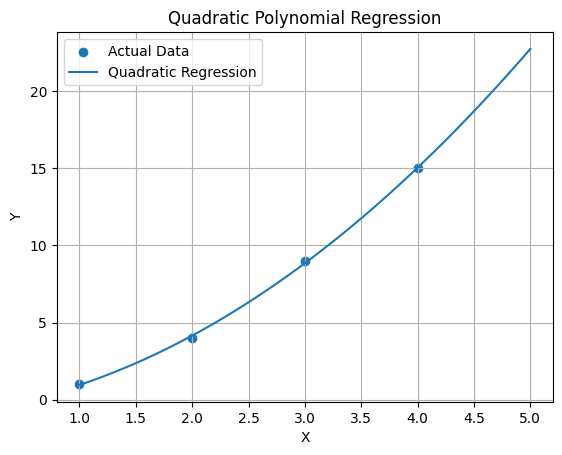

In [7]:
# Plot
X_curve = np.linspace(1, 5, 100).reshape(-1, 1)

X_curve_poly = poly.transform(X_curve)

Y_curve = model.predict(X_curve_poly)

plt.scatter(X, Y, label="Actual Data")

plt.plot(
    X_curve,
    Y_curve,
    label="Quadratic Regression"
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Quadratic Polynomial Regression")

plt.legend()
plt.grid(True)
plt.show()